In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from ucimlrepo import fetch_ucirepo

horse_colic = fetch_ucirepo(id=47)

X = horse_colic.data.features.copy()
y = horse_colic.data.targets.copy()

data = pd.concat([X, y], axis=1)
target_col = y.columns[0]

numeric_cols = data.select_dtypes(include=np.number).columns.tolist()

print("Размер датасета:", data.shape)
print("Целевой признак:", target_col)
print("Числовые признаки:", numeric_cols)

data.head()

Размер датасета: (368, 28)
Целевой признак: surgical_lesion
Числовые признаки: ['surgery', 'age', 'hospital_number', 'rectal_temperature', 'pulse', 'respiratory_rate', 'temperature_of_extremities', 'peripheral_pulse', 'mucous_membranes', 'capillary_refill_time', 'pain', 'peristalsis', 'abdominal_distension', 'nasogastric_tube', 'nasogastric_reflux', 'nasogastric_reflux_ph', 'rectal_examination_feces', 'abdomen', 'packed_cell_volume', 'total_protein', 'abdominocentesis_appearance', 'abdominocentesis_total_protein', 'outcome', 'lesion_site', 'lesion_type', 'lesion_subtype', 'cp_data', 'surgical_lesion']


,surgery,age,hospital_number,rectal_temperature,pulse,respiratory_rate,temperature_of_extremities,peripheral_pulse,mucous_membranes,capillary_refill_time,...,packed_cell_volume,total_protein,abdominocentesis_appearance,abdominocentesis_total_protein,outcome,lesion_site,lesion_type,lesion_subtype,cp_data,surgical_lesion
0,2.0,1,530101,38.5,66.0,28.0,3.0,3.0,NaN,2.0,...,45.0,8.4,NaN,NaN,2.0,11300,0,0,2,2
1,1.0,1,534817,39.2,88.0,20.0,NaN,NaN,4.0,1.0,...,50.0,85.0,2.0,2.0,3.0,2208,0,0,2,2
2,2.0,1,530334,38.3,40.0,24.0,1.0,1.0,3.0,1.0,...,33.0,6.7,NaN,NaN,1.0,0,0,0,1,2
3,1.0,9,5290409,39.1,164.0,84.0,4.0,1.0,6.0,2.0,...,48.0,7.2,3.0,5.3,2.0,2208,0,0,1,1
4,2.0,1,530255,37.3,104.0,35.0,NaN,NaN,6.0,2.0,...,74.0,7.4,NaN,NaN,2.0,4300,0,0,2,2


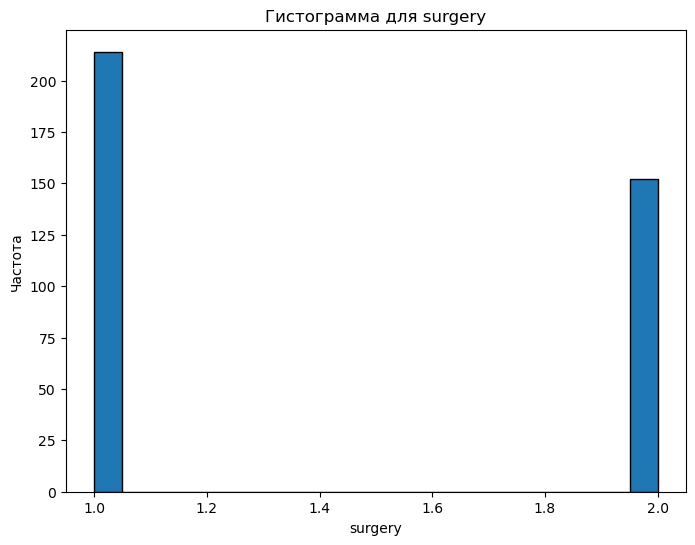

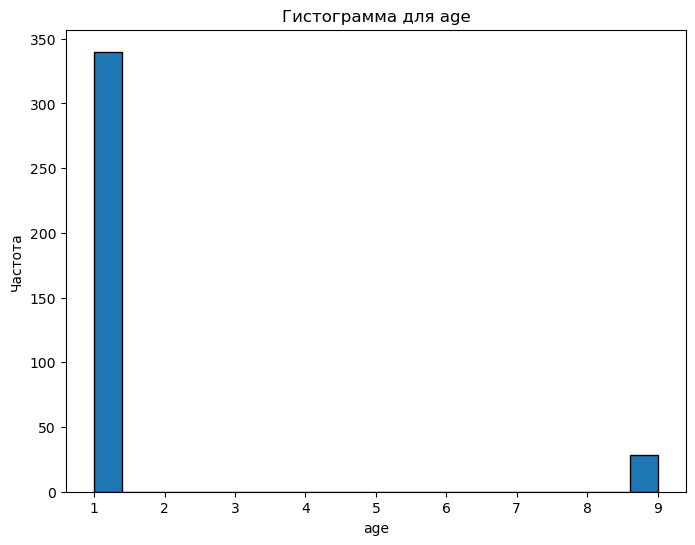

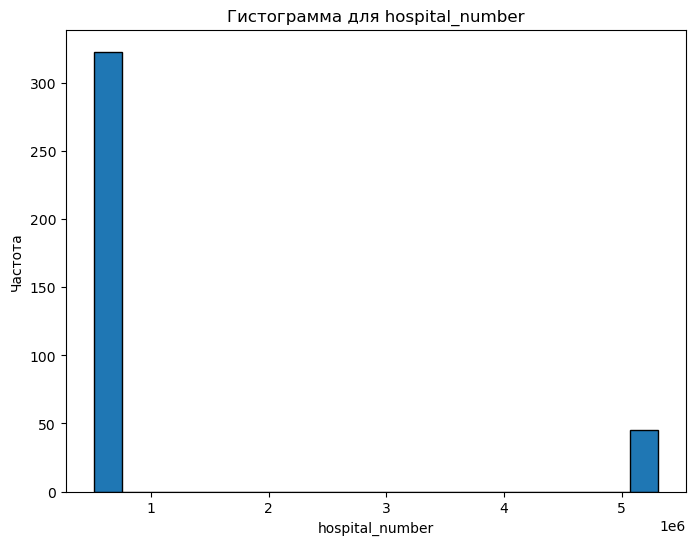

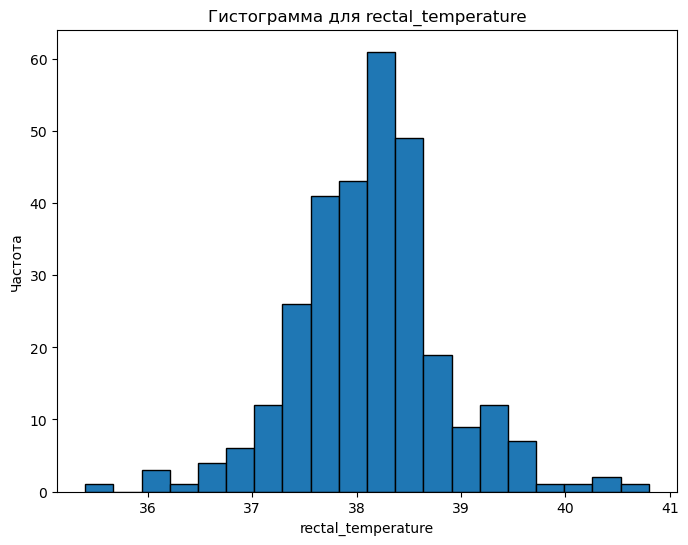

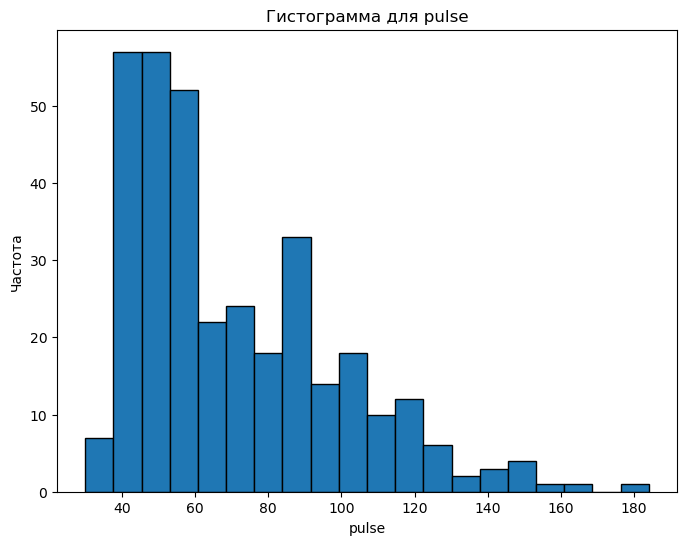

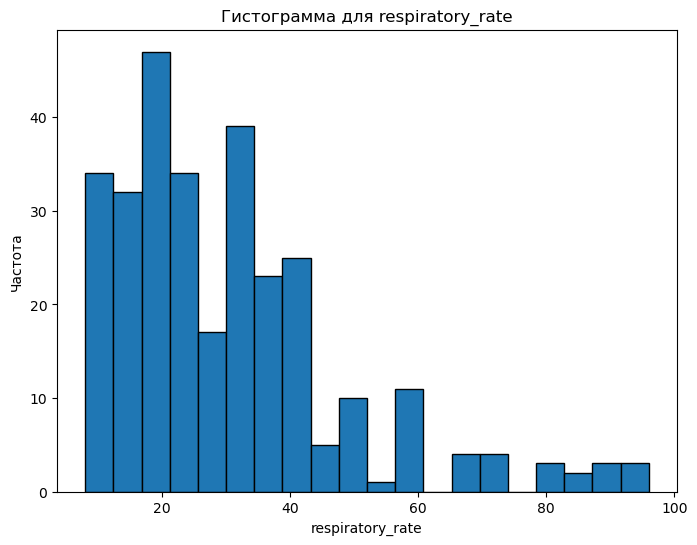

In [2]:
columns = numeric_cols[:6]

for col in columns:
    plt.figure(figsize=(8, 6))
    plt.hist(data[col].dropna(), bins=20, edgecolor="black")
    plt.title(f"Гистограмма для {col}")
    plt.xlabel(col)
    plt.ylabel("Частота")
    plt.show()

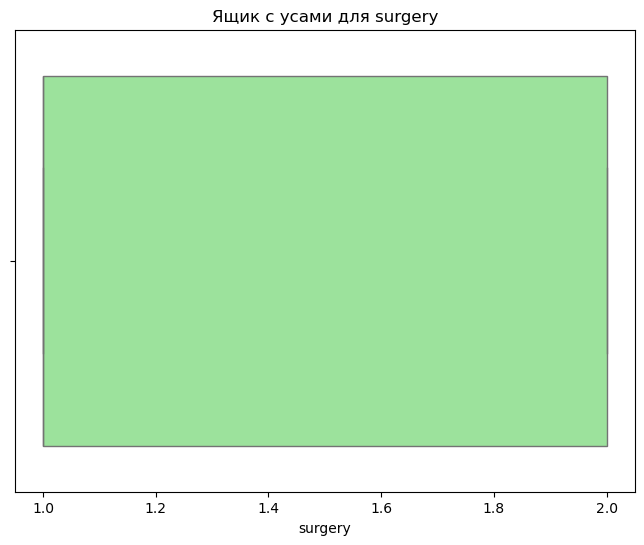

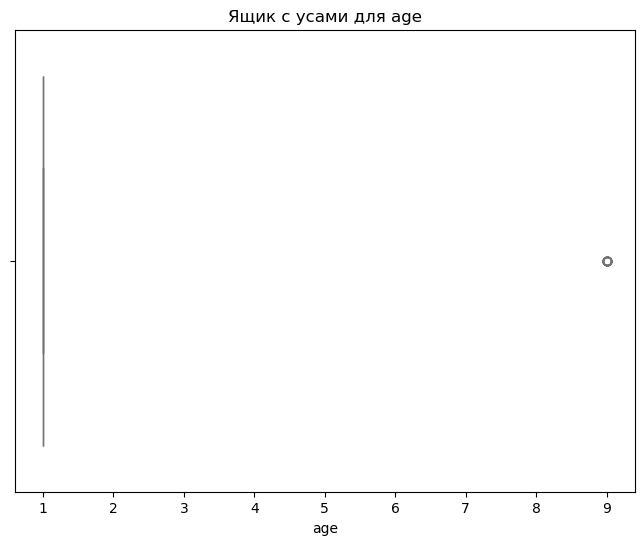

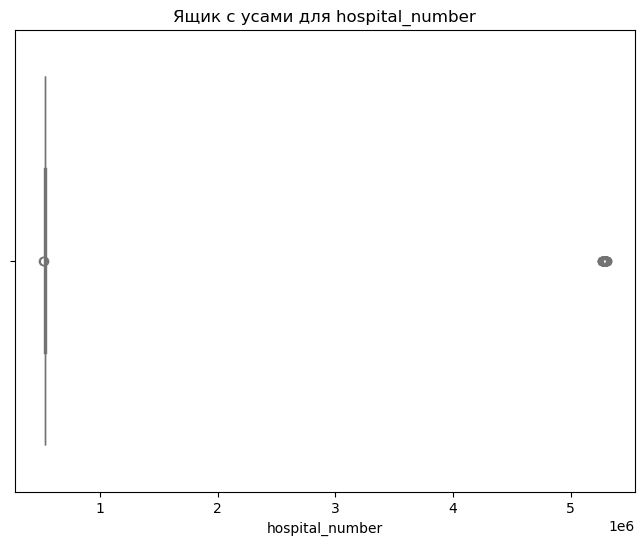

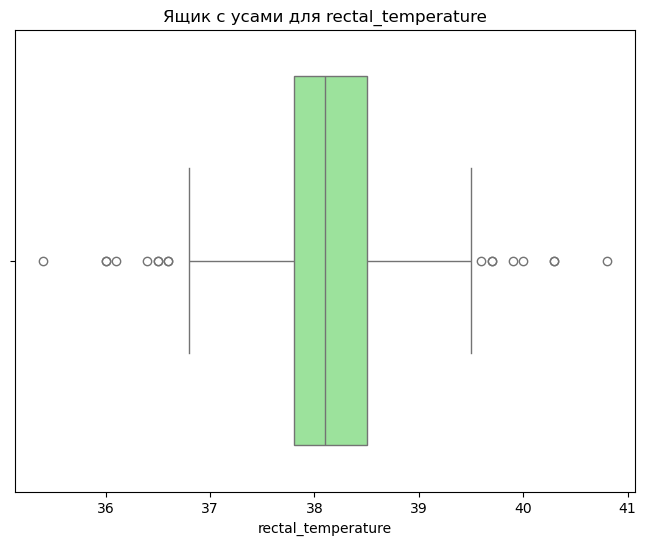

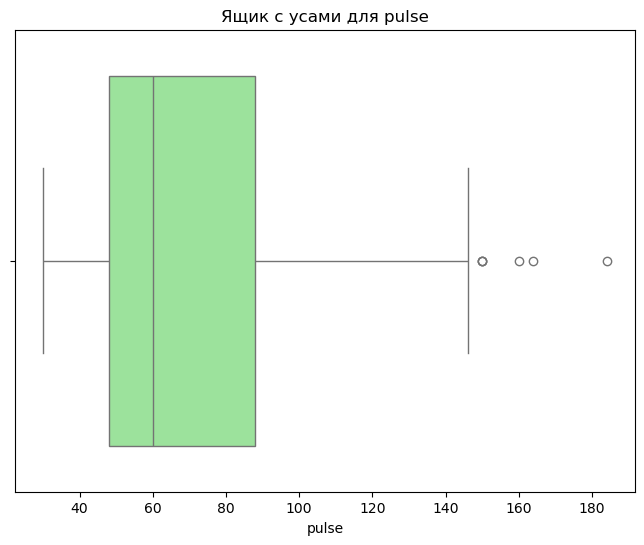

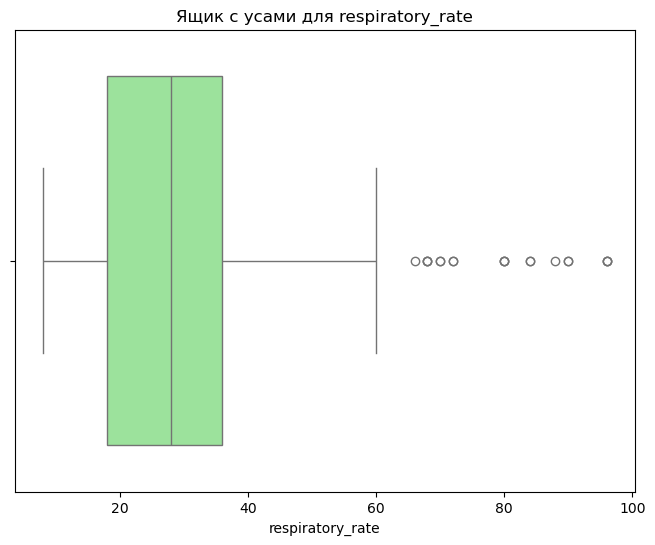

In [3]:
columns = numeric_cols[:6]

for col in columns:
    plt.figure(figsize=(8, 6))

    sns.boxplot(
        x=data[col].dropna(),
        color='lightgreen'
    )

    plt.title(f'Ящик с усами для {col}')
    plt.xlabel(col)

    plt.show()

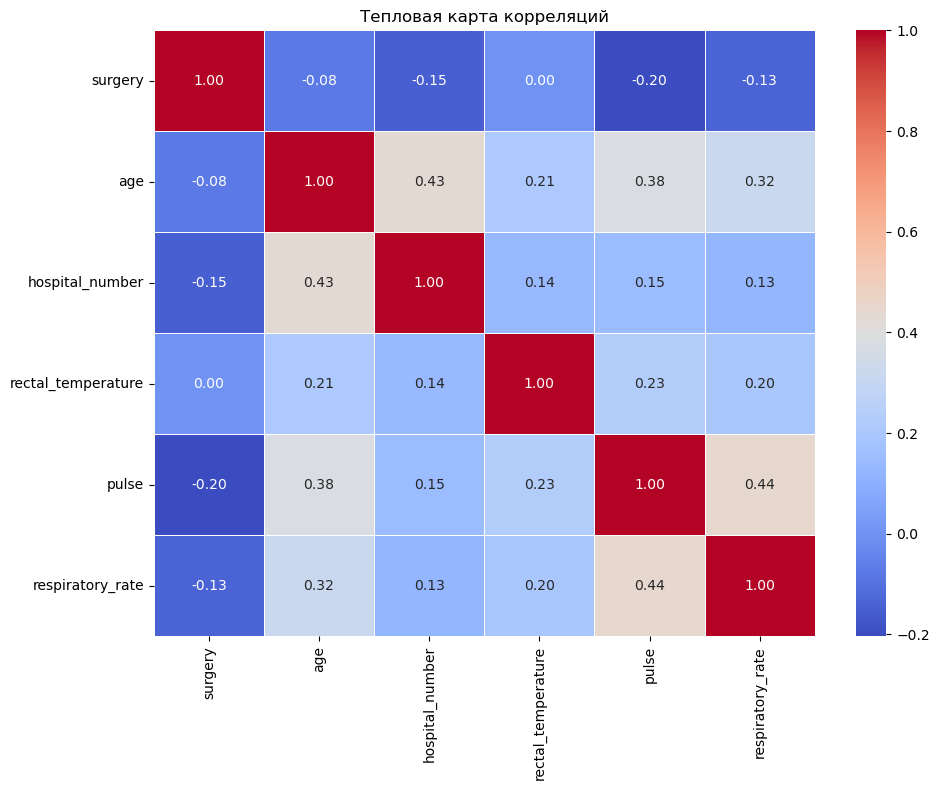

In [4]:
correlation_matrix = data[columns].corr(method='spearman')

plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Тепловая карта корреляций')

plt.tight_layout()
plt.show()